# Разработка системы интеллектуального ранжирования рекламных предложений на основе машинного обучения

Выпускная работа по курсу «Data Scientist». Автор: Андрей Васильев.

## Задача

Рекламный сервис показывает предложения партнёрских сетей на сайтах компании. В
витрине несколько мест, а предложений больше, поэтому система выбирает, что
показать и в каком порядке. Сейчас выбор делает жёсткое правило без машинного
обучения.

Работа проверяет, можно ли выбирать лучше. Ранжирование строится не по
вероятности клика, а по ожидаемому доходу показа:

**ожидаемый доход = P(клик) × P(конверсия при клике) × последняя известная выплата**

Основная метрика соответствует задаче сервиса: получать больше дохода с показа.
Вероятностей клика и конверсии для этого недостаточно, поскольку выплаты
по предложениям различаются. Например, при вероятности клика 10% оффер
с конверсией 20% и выплатой 50 рублей даёт 1 рубль ожидаемого дохода с показа.
Оффер с конверсией 10% и выплатой 300 рублей даёт 3 рубля.

Под доходом здесь понимаю поступления от партнёрских сетей в рублях. Расходы в этой работе
не оцениваю. ROC-AUC и Average Precision использую для проверки моделей
вероятностей, NDCG для проверки порядка карточек.

## План работы

1. Загрузка и осмотр данных
2. Очистка выборки
3. Целевые переменные
4. Признаки
5. Разбиение на обучение и проверку
6. Базовые решения для сравнения
7. Модель клика
8. Модель конверсии
9. Ожидаемый доход и сравнение всех решений
10. Выводы и ограничения

## 1. Загрузка и осмотр данных

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 50)

DATA = Path.cwd().parent / "datasets"
files = sorted(DATA.glob("impressions-*.csv"))
print("файлы выгрузки:", [f.name for f in files])

файлы выгрузки: ['impressions-2026-08.csv', 'impressions-2026-09.csv']


Данные это выгрузка показов рекламы: одна строка равна одному показу одного
предложения одному посетителю.

При чтении задаю два параметра явно. Коды регионов читаю строкой, иначе `08`
превратится в 8 и ведущий ноль потеряется. И отключаю стандартный список пустых
значений, иначе код страны Намибии `NA` будет прочитан как пропуск.

In [2]:
date_cols = ["impression_at", "visit_started_at", "click_at", "conversion_at"]

df = pd.concat(
    [pd.read_csv(f, parse_dates=date_cols, dtype={"geo_region": "string"},
                 keep_default_na=False, na_values="") for f in files],
    ignore_index=True,
).sort_values("impression_at").reset_index(drop=True)

# Сохраняю согласованную проверку с 1 по 14 сентября и семь дней ожидания.
TEST_START = pd.Timestamp("2026-09-01")
EVALUATION_END = pd.Timestamp("2026-09-15")
print(f"Показов за правой границей: {df['impression_at'].ge(EVALUATION_END).sum():,}")
df = df[df["impression_at"].lt(EVALUATION_END)].copy()
assert df["offer_impression_id"].is_unique

print(f"строк: {len(df):,}".replace(",", " "))
print(f"колонок: {df.shape[1]}")
print(f"период: {df['impression_at'].min():%d.%m.%Y} по {df['impression_at'].max():%d.%m.%Y}")
df.head()

Показов за правой границей: 328,215


строк: 3 400 653
колонок: 43
период: 01.08.2026 по 14.09.2026


,offer_impression_id,advertising_impression_id,impression_at,visitor_id,visit_id,visit_started_at,site_id,placement_id,position_id,advertising_id,advertising_type,source_id,campaign_id,page_url_id,landing_page_url_id,http_referrer_host,user_agent_id,device_type,os_name,browser_name,ip_id,geo_country,geo_region,bot_type,position_index,is_swap,preset_id,offer_id,partner_offer_id,partner_id,creative_id,partner_offer_payout_current,partner_offer_bonus_current,target_click,click_id,click_at,target_conversion,conversion_id,conversion_at,conversion_payout,conversion_bonus,conversion_revoked,conversion_origin
0,1424887,1009382.0,2026-08-01 00:00:36,450012.0,578039.0,2026-08-01 00:00:35,39,128,5,52,banner,2.0,52.0,984389.0,984389.0,NaN,20621.0,phablet,Android,Mi Browser,276623.0,RU,NIZ,NaN,0,0.0,31,17,31,2,34,40,10,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
1,1424888,1009383.0,2026-08-01 00:00:43,450013.0,578040.0,2026-08-01 00:00:42,28,77,5,52,banner,12.0,383.0,984390.0,984390.0,NaN,34531.0,smartphone,Android,Yandex Browser,276653.0,RU,<NA>,NaN,0,0.0,33,27,30,7,36,0,0,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
2,1424889,1009384.0,2026-08-01 00:00:48,450014.0,578041.0,2026-08-01 00:00:47,39,128,5,52,banner,1.0,87.0,984391.0,984391.0,NaN,2004.0,smartphone,Android,Chrome Mobile,10105.0,RU,<NA>,NaN,0,0.0,57,33,41,2,52,0,0,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
3,1424890,1009385.0,2026-08-01 00:00:55,450015.0,578042.0,2026-08-01 00:00:53,28,77,5,52,banner,3.0,3.0,984392.0,984392.0,ls-trck.ru,2004.0,smartphone,Android,Chrome Mobile,196445.0,RU,NIZ,NaN,0,0.0,31,17,31,2,34,40,10,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
4,1424891,1009386.0,2026-08-01 00:01:07,450017.0,578044.0,2026-08-01 00:01:06,31,130,5,52,banner,3.0,41.0,984394.0,984394.0,pxl.leads.su,119.0,smartphone,Android,Chrome Mobile,158977.0,DE,HE,NaN,0,0.0,57,33,41,2,52,0,0,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN


In [3]:
print("Основные показатели выгрузки")
print(f"показов:   {len(df):,}".replace(",", " "))
print(f"кликов:    {df['target_click'].sum():,} (CTR {df['target_click'].mean():.2%})".replace(",", " "))
print(f"конверсий: {df['target_conversion'].sum():,}".replace(",", " "))
print(f"конверсия от кликов: {df.loc[df['target_click'] == 1, 'target_conversion'].mean():.1%}")
print(f"посетителей: {df['visitor_id'].nunique():,}".replace(",", " "))
print(f"предложений: {df['offer_id'].nunique()}, связок с партнёрами: {df['partner_offer_id'].nunique()}")

Основные показатели выгрузки
показов:   3 400 653
кликов:    216 825 (CTR 6.38%)
конверсий: 80 349
конверсия от кликов: 37.1%
посетителей: 372 275
предложений: 37, связок с партнёрами: 41


Смотрю, как показы распределены по дням и меняется ли набор предложений.

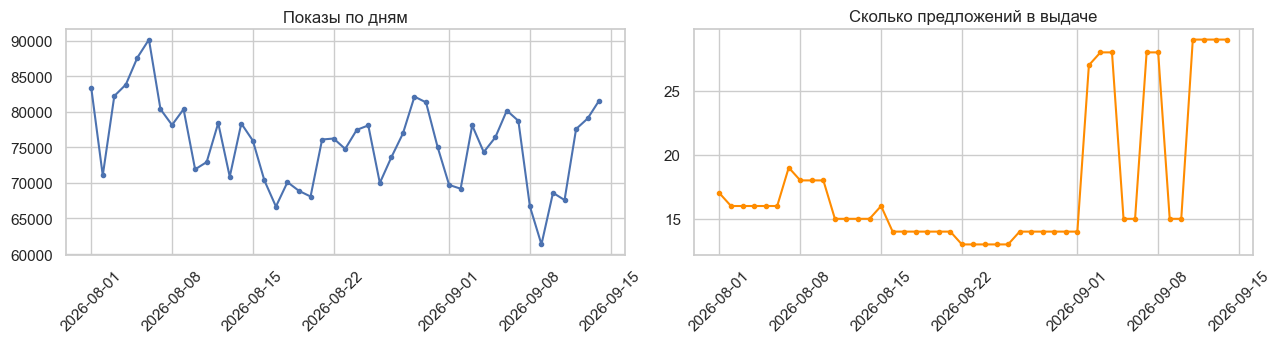

In [4]:
daily = df.groupby(df["impression_at"].dt.date).agg(
    shows=("target_click", "size"),
    offers=("offer_id", "nunique"),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.6))
ax1.plot(daily.index, daily["shows"], marker="o", markersize=3)
ax1.set_title("Показы по дням")
ax2.plot(daily.index, daily["offers"], marker="o", markersize=3, color="darkorange")
ax2.set_title("Сколько предложений в выдаче")
for ax in (ax1, ax2):
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Сравниваю объём трафика и состав предложений по дням. Даже при похожем общем
объёме новые связки могут заметно менять задачу. Поэтому использую разбиение
по времени и отдельно проверяю предложения, которых не было при обучении.

Проверяю главное предположение работы: что предложения различаются по цене
конверсии. Если бы все стоили одинаково, ранжировать по деньгам не имело бы
смысла.

In [5]:
money = df[df["target_conversion"] == 1].groupby("partner_offer_id").agg(
    conversions=("target_conversion", "size"),
    median_payout=("conversion_payout", "median"),
    turnover=("conversion_payout", "sum"),
).sort_values("turnover", ascending=False)
money["turnover_share"] = (money["turnover"] / money["turnover"].sum() * 100).round(1)
display(money.head(8))

print(f"медианная выплата: от {money['median_payout'].min():.0f} до {money['median_payout'].max():.0f} руб")

,conversions,median_payout,turnover,turnover_share
partner_offer_id,,,,
36,7661,750.0,5745750.0,43.4
30,4897,300.0,1469100.0,11.1
31,29848,40.0,1193920.0,9.0
38,4326,154.0,646399.0,4.9
26,869,770.0,636930.0,4.8
6,7561,50.0,378050.0,2.9
37,832,453.0,376896.0,2.8
34,739,450.0,332550.0,2.5


медианная выплата: от 30 до 5950 руб


Разброс в десятки раз, предположение подтвердилось.

Отдельно проверяю цену из справочника. Это снимок на дату выгрузки,
а не история согласованных ставок на момент каждого показа.

In [6]:
nominal = df.groupby("partner_offer_id")["partner_offer_payout_current"].first()
zero_links = nominal[nominal == 0].index
print(f"связок со ставкой 0 в справочнике: {len(zero_links)} из {len(nominal)}")
print(f"на них приходится {df['partner_offer_id'].isin(zero_links).mean():.1%} показов")
print(f"при этом реальных выплат по ним: {df[df['partner_offer_id'].isin(zero_links)]['conversion_payout'].sum():,.0f} руб".replace(",", " "))

связок со ставкой 0 в справочнике: 37 из 41
на них приходится 81.0% показов


при этом реальных выплат по ним: 6 162 576 руб


У большинства связок в справочнике стоит ноль, хотя деньги по ним реально
приходят: в колонке лежит номинал на момент выгрузки, а фактическая сумма
приходит от партнёра вместе с уведомлением о конверсии. Поэтому ставку на дату показа восстанавливаю по последней
уже поступившей конверсии связки. Справочную ставку оставляю отдельным признаком.

## 2. Очистка выборки

Убираю три группы строк. Каждая из них описывает не поведение посетителя, а
что-то другое.

In [7]:
before = len(df)

# 1. Роботы поисковых систем: у них своя колонка, заполнено значит бот
is_bot = df["bot_type"].notna()
print(f"роботы: CTR {df.loc[is_bot, 'target_click'].mean():.1%} против "
      f"{df.loc[~is_bot, 'target_click'].mean():.1%} у людей, "
      f"конверсий {df.loc[is_bot, 'target_conversion'].sum()}")

# 2. Подменённые карточки: после клика карточка скрывается, а снизу подставляется
# новая. Такой показ возникает только потому, что клик уже случился. Определяю по
# времени: карточки первого показа появляются вместе, подмена отстаёт.
first_in_block = df.groupby("advertising_impression_id")["impression_at"].transform("min")
lag = (df["impression_at"] - first_in_block).dt.total_seconds()
is_swap = (lag > 1) | df["advertising_impression_id"].isna()

# 3. Исследование относится к конверсиям через постбэк.
# Исключаю связки с оплатой за клик, сохраняя остальные связки того же партнёра.
cpc_links = set(df.loc[df["conversion_origin"].eq("click"), "partner_offer_id"])
postback_links = set(df.loc[df["conversion_origin"].eq("postback"), "partner_offer_id"])
assert not (cpc_links & postback_links), "Есть связки со смешанным типом оплаты; нужно разделить их периоды"
was_cpc = df["partner_offer_id"].isin(cpc_links)
print("Связки с оплатой за клик:", sorted(cpc_links))

df = df[~(is_bot | is_swap | was_cpc)].copy()

print(f"\nубрано роботов: {is_bot.sum():,}".replace(",", " "))
print(f"убрано подмен: {is_swap.sum():,}".replace(",", " "))
print(f"убрано по оплате за клик: {was_cpc.sum():,}".replace(",", " "))
print(f"осталось: {len(df):,} из {before:,} ({len(df) / before:.1%})".replace(",", " "))

роботы: CTR 20.2% против 5.9% у людей, конверсий 476


Связки с оплатой за клик: [5, 12, 64]



убрано роботов: 120 481
убрано подмен: 83 302
убрано по оплате за клик: 115 983
осталось: 3 081 049 из 3 400 653 (90.6%)


## 3. Целевые переменные

Первая модель предсказывает клик и учится на показах. Вторая предсказывает
конверсию после клика и учится на кликах. Их вероятности затем перемножаю.

Сохраняю прежнее исключение связок с большим числом кликов без конверсий.
Отсутствие конверсий само по себе не доказывает неисправность уведомлений,
поэтому это ограничение обучающей выборки.


In [8]:
clicks = df[df["target_click"] == 1]
by_link = clicks.groupby("partner_offer_id").agg(
    clicks=("target_click", "size"),
    conversions=("target_conversion", "sum"),
)
silent = by_link[(by_link["conversions"] == 0) & (by_link["clicks"] >= 100)].index
display(by_link.loc[silent])

df["revenue"] = np.where(df["target_conversion"] == 1,
                         df["conversion_payout"] + df["conversion_bonus"], 0)
df["stage2"] = (df["target_click"] == 1) & (~df["partner_offer_id"].isin(silent))

print(f"первая ступень: {len(df):,} показов, {df['target_click'].sum():,} кликов".replace(",", " "))
print(f"вторая ступень: {df['stage2'].sum():,} кликов, ".replace(",", " ")
      + f"{df.loc[df['stage2'], 'target_conversion'].sum():,} конверсий".replace(",", " "))
print(f"доход за период: {df['revenue'].sum():,.0f} руб".replace(",", " "))

,clicks,conversions
partner_offer_id,,
15,850,0
44,402,0


первая ступень: 3 081 049 показов  177 371 кликов
вторая ступень: 176 119 кликов  68 112 конверсий
доход за период: 12 902 240 руб


## 4. Признаки

Признаком может быть только то, что сервис знает **до** показа карточки. Всё, что
становится известно после (время клика, данные конверсии), в модель не идёт.

По этой же причине не использую позицию карточки в витрине и креатив: их выбирает
та самая система, которую мы заменяем, то есть в момент выбора предложения они
ещё не определены.

Признаки делю на четыре группы.

In [9]:
# Группа 1: время показа
df["hour"] = df["impression_at"].dt.hour
df["weekday"] = df["impression_at"].dt.dayofweek
df["weekend"] = (df["weekday"] >= 5).astype(int)
df["visit_depth"] = (df["impression_at"] - df["visit_started_at"]).dt.total_seconds()

# Группа 2: история посетителя, считается по прошлым показам
df["visitor_shows"] = df.groupby("visitor_id").cumcount()
df["visitor_clicks"] = df.groupby("visitor_id")["target_click"].cumsum() - df["target_click"]
df["visitor_offer_shows"] = df.groupby(["visitor_id", "offer_id"]).cumcount()
df["since_last_show"] = df.groupby("visitor_id")["impression_at"].diff().dt.total_seconds()

# Группа 3: насколько редкие у показа страница и устройство
for col, name in [("page_url_id", "page"), ("ip_id", "ip"), ("user_agent_id", "ua")]:
    df[f"{name}_count"] = df.groupby(col).cumcount()

print("признаков времени и истории готово")

признаков времени и истории готово


Важная деталь про историю посетителя. Карточки одного показа витрины идут в
данных подряд, поэтому счётчик внутри витрины растёт от карточки к карточке и
фактически показывает номер места. Но в момент выбора места ещё не назначены и
история у всех кандидатов одинаковая.

Поэтому всем карточкам одной витрины ставлю одно значение: то, которое было до
её показа.

In [10]:
counters = ["visit_depth", "visitor_shows", "visitor_clicks", "since_last_show",
            "page_count", "ip_count", "ua_count"]

for col in counters:
    df[col] = df.groupby("advertising_impression_id")[col].transform("first")

# Длинный хвост сжимаю логарифмом: разница между первым и десятым показом важна,
# между тысячным и тысяча первым уже нет
for col in ["visitor_shows", "visitor_clicks", "visitor_offer_shows",
            "page_count", "ip_count", "ua_count"]:
    df[col] = np.log1p(df[col])

df[counters + ["visitor_offer_shows"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
visit_depth,3081049.0,160.81,333.40,-1.0,7.00,40.00,167.00,8836.00
visitor_shows,3081049.0,1.40,1.01,0.0,0.69,1.39,2.30,7.41
visitor_clicks,3081049.0,0.17,0.38,0.0,0.00,0.00,0.00,3.58
since_last_show,2735965.0,12333.25,103325.06,0.0,0.00,15.00,147.00,3842623.00
page_count,3081049.0,0.61,1.59,0.0,0.00,0.00,0.69,9.53
ip_count,3081049.0,2.03,1.27,0.0,1.10,1.95,2.94,7.47
ua_count,3081049.0,7.33,3.65,0.0,4.14,7.61,10.84,12.72
visitor_offer_shows,3081049.0,0.26,0.47,0.0,0.00,0.00,0.69,5.32


Четвёртая группа это статистика кликов и конверсий предложения. Доли сглаживаются
к общему уровню, чтобы небольшое число событий не давало слишком резкую оценку.

Стоимость конверсии заранее согласована для каждой связки оффера и партнёрской
сети. В исторических данных восстанавливаю её по последней конверсии той же
связки, поступившей до показа:

`payout_link(t) = conversion_payout(j) + conversion_bonus(j)`,
где `j` имеет максимальное `conversion_at < t` среди конверсий этой связки.

Сумму не усредняю и не сглаживаю. После поступления новой суммы использую её
для следующих показов. Временем доступности считаю conversion_at, время
создания конверсии в сервисе. Конверсию ровно в момент показа не использую,
так как порядок событий с одинаковой временной отметкой неизвестен.

До первой конверсии ставка неизвестна (NaN). Такие показы оставляю в обучении
вероятностей, но для денежного сравнения беру только витрины с известными
ставками всех карточек. При смене тарифа возможна задержка до первой конверсии
с новой суммой. Ниже отдельно проверяю точность восстановления ставки.


In [11]:
SMOOTH = 100
mean_ctr = df["target_click"].mean()
mean_cr = df.loc[df["target_click"] == 1, "target_conversion"].mean()

for key, name in [("offer_id", "offer"), ("partner_offer_id", "link"), ("partner_id", "partner")]:
    shows_before = df.groupby(key).cumcount()
    clicks_before = df.groupby(key)["target_click"].cumsum() - df["target_click"]
    df[f"ctr_{name}"] = (clicks_before + SMOOTH * mean_ctr) / (shows_before + SMOOTH)

    conv_before = df.groupby(key)["target_conversion"].cumsum() - df["target_conversion"]
    df[f"cr_{name}"] = (conv_before + SMOOTH * mean_cr) / (clicks_before + SMOOTH)

# Выплата: последнее известное значение для связки, без усреднения и обрезки.
def last_known_payout(shows):
    events = shows.loc[shows["target_conversion"].eq(1),
                       ["partner_offer_id", "conversion_at", "revenue"]].copy()
    assert events["conversion_at"].notna().all(), "У конверсии нет времени поступления"
    # Одновременные события одной связки должны сообщать одну и ту же ставку.
    assert events.groupby(["partner_offer_id", "conversion_at"])["revenue"].nunique().le(1).all()
    events = events.drop_duplicates(["partner_offer_id", "conversion_at"])
    events = events.rename(columns={"conversion_at": "payout_observed_at",
                                    "revenue": "payout_link"})
    left = shows[["partner_offer_id", "impression_at"]].copy()
    left["row_index"] = shows.index
    matched = pd.merge_asof(
        left.sort_values("impression_at"), events.sort_values("payout_observed_at"),
        by="partner_offer_id", left_on="impression_at", right_on="payout_observed_at",
        direction="backward", allow_exact_matches=False,
    ).set_index("row_index").reindex(shows.index)
    return matched[["payout_link", "payout_observed_at"]]


df[["payout_link", "payout_observed_at"]] = last_known_payout(df)
known_payout = df["payout_link"].notna()
assert (df.loc[known_payout, "payout_observed_at"] < df.loc[known_payout, "impression_at"]).all()
df["payout_nominal"] = df["partner_offer_payout_current"]
print(f"Ставка известна до показа: {known_payout.mean():.2%} показов")

df[["ctr_offer", "ctr_link", "cr_link", "payout_link"]].describe().round(3).T

Ставка известна до показа: 97.78% показов


,count,mean,std,min,25%,50%,75%,max
ctr_offer,3081049.0,0.058,0.044,0.009,0.033,0.056,0.064,0.239
ctr_link,3081049.0,0.058,0.045,0.009,0.032,0.054,0.061,0.239
cr_link,3081049.0,0.366,0.288,0.035,0.171,0.231,0.423,0.948
payout_link,3012545.0,375.409,834.040,50.000,80.000,263.000,410.000,5950.000


In [12]:
NUM_COLS = ["hour", "weekday", "weekend", "visit_depth",
            "visitor_shows", "visitor_clicks", "visitor_offer_shows", "since_last_show",
            "page_count", "ip_count", "ua_count",
            "ctr_offer", "ctr_link", "ctr_partner", "cr_link", "cr_partner",
            "payout_link", "payout_nominal"]

CAT_COLS = ["site_id", "placement_id", "position_id", "advertising_id", "advertising_type",
            "source_id", "campaign_id", "device_type", "os_name", "browser_name",
            "geo_country", "geo_region", "preset_id", "offer_id", "partner_offer_id", "partner_id"]

for col in CAT_COLS:
    df[col] = df[col].astype(str)

FEATURES = NUM_COLS + CAT_COLS
print(f"числовых признаков: {len(NUM_COLS)}, категориальных: {len(CAT_COLS)}")
print("категории оставляю как есть: CatBoost умеет работать с ними напрямую")

# Сохраняю подготовленную таблицу, чтобы второй ноутбук не повторял всю подготовку
# Для моделей вероятностей сохраняю все показы, в том числе без известной ставки.
df.to_parquet(Path.cwd().parent / "cache" / "prepared.parquet", index=False)

числовых признаков: 18, категориальных: 16
категории оставляю как есть: CatBoost умеет работать с ними напрямую


## 5. Разбиение на обучение и проверку

Обучение использует август. На проверку откладываю показы с 1 по 14 сентября.
Границы заданы до расчёта результата. Показы с 15 по 18 сентября сохраняются
в исходных файлах, но не входят в текущую проверку: для них ещё не прошло
семь дней ожидания исходов. Случайное перемешивание периодов не использую.

In [13]:
border = TEST_START
model_df = df
train = model_df[model_df["impression_at"] < border]
test = model_df[model_df["impression_at"] >= border]

print(f"Показы без ставки оставлены для обучения вероятностей: {df['payout_link'].isna().sum():,}")

print(f"граница: {border:%d.%m.%Y}")
print(f"обучение: {len(train):,} показов, {len(train) / len(model_df):.0%}".replace(",", " "))
print(f"проверка: {len(test):,} показов, {len(test) / len(model_df):.0%}".replace(",", " "))
print(f"кликов в проверке: {test['target_click'].sum():,}".replace(",", " "))
print(f"конверсий в проверке: {test['target_conversion'].sum():,}".replace(",", " "))

new_offers = set(test["offer_id"]) - set(train["offer_id"])
print(f"предложений, которых не было в обучении: {len(new_offers)}")

Показы без ставки оставлены для обучения вероятностей: 68,504
граница: 01.09.2026
обучение: 2 146 697 показов  70%
проверка: 934 352 показов  30%
кликов в проверке: 50 049
конверсий в проверке: 20 126
предложений, которых не было в обучении: 15


### Проверка восстановления выплаты

Сравниваю ставку, известную до показа, с последующей фактической выплатой.
Оба способа проверяю на одних и тех же 20 120 конверсиях сентября с историей
ставки. MAE измеряется в рублях за конверсию. Прежний расчёт среднего
с ограничением больших выплат оставлен только для сравнения ошибки.

Последняя известная ставка совпала с фактической выплатой в 99,98% случаев.
MAE снизилась с 15,0509 до 0,0027 рубля. Ещё 6 тестовых конверсий не имели
истории ставки и в это сравнение не вошли. Эти числа показывают точность
денежного множителя, а качество вероятностей проверяется отдельно.


In [14]:
# Проверка ставки на тестовых конверсиях: используется информация до показа.
period_test = df[df["impression_at"] >= border]
paid_test = period_test[period_test["target_conversion"].eq(1)]
check = paid_test[paid_test["payout_link"].notna()]

# Прежний расчёт воспроизведён только для сравнения ошибки, в модели не используется.
cap_old = df.loc[df["target_conversion"].eq(1), "revenue"].quantile(0.99)
r_old = df["revenue"].clip(upper=cap_old)
sum_old = r_old.groupby(df["partner_offer_id"]).cumsum() - r_old
n_old = df.groupby("partner_offer_id")["target_conversion"].cumsum() - df["target_conversion"]
mean_old = df.loc[df["target_conversion"].eq(1), "revenue"].mean()
payout_old = (sum_old + SMOOTH * mean_old) / (n_old + SMOOTH)

payout_check = pd.DataFrame([
    {"способ": name, "конверсий": len(check),
     "точное совпадение, %": 100 * np.isclose(estimate, check["revenue"]).mean(),
     "MAE, руб.": np.abs(estimate - check["revenue"]).mean()}
    for name, estimate in [
        ("прежнее сглаженное среднее", payout_old.loc[check.index]),
        ("последняя известная выплата", check["payout_link"]),
    ]
]).set_index("способ")
display(payout_check.round(4))
print(f"Без истории ставки: {len(paid_test) - len(check)} из {len(paid_test)} тестовых конверсий")
print(f"Тестовые показы с известной ставкой: {period_test['payout_link'].notna().mean():.2%}")

# Примеры: какая прошлая конверсия задавала ставку на момент показа.
display(check[["partner_offer_id", "impression_at", "payout_observed_at",
               "payout_link", "conversion_at", "revenue"]].head(5))

,конверсий,"точное совпадение, %","MAE, руб."
способ,,,
прежнее сглаженное среднее,20120,0.0000,15.0509
последняя известная выплата,20120,99.9801,0.0027


Без истории ставки: 6 из 20126 тестовых конверсий
Тестовые показы с известной ставкой: 98.13%


,partner_offer_id,impression_at,payout_observed_at,payout_link,conversion_at,revenue
2371539,6,2026-09-01 00:03:18,2026-08-31 23:45:17,50.0,2026-09-01 00:55:24,50.0
2371565,34,2026-09-01 00:04:16,2026-09-01 00:00:24,450.0,2026-09-01 00:48:12,450.0
2371590,31,2026-09-01 00:04:41,2026-09-01 00:00:21,50.0,2026-09-01 00:50:24,50.0
2371617,6,2026-09-01 00:07:09,2026-09-01 00:05:16,50.0,2026-09-01 00:55:22,50.0
2371709,38,2026-09-01 00:12:23,2026-08-31 23:49:17,154.0,2026-09-01 01:04:05,154.0


## 6. Базовые решения для сравнения

Без базы сравнения метрика модели ничего не значит. Беру четыре простых правила
сортировки предложений:

1. случайный порядок, нижняя граница;
2. исторический CTR предложения, то есть популярность;
3. цена из справочника, проверка «а не решается ли задача бизнес-правилом»;
4. ожидаемый доход, посчитанный из накопленной статистики без всякого обучения.

Действующий алгоритм сервиса в базы не входит, и это важная оговорка. Он
детерминированный: кандидат либо показывается, либо нет, вероятности между ними
нет. Оценить по логам, что было бы при другом выборе, в такой ситуации
математически невозможно, для этого нужен A/B-тест.

In [15]:
np.random.seed(42)
baselines = {
    "случайный порядок": np.random.rand(len(test)),
    "популярность (CTR оффера)": test["ctr_offer"].to_numpy(),
    "цена из справочника": test["payout_nominal"].to_numpy(),
    "доход по статистике": (test["ctr_link"] * test["cr_link"] * test["payout_link"]).to_numpy(),
}

known = test["payout_link"].notna().to_numpy()
print(f"Базовые правила: общая выборка из {known.sum():,} показов с известной ставкой")

result = pd.DataFrame([
    {"решение": name,
     "ROC-AUC": roc_auc_score(test.loc[known, "target_click"], score[known]),
     "PR-AUC": average_precision_score(test.loc[known, "target_click"], score[known])}
    for name, score in baselines.items()
]).set_index("решение")
display(result.round(4))

Базовые правила: общая выборка из 916,847 показов с известной ставкой


,ROC-AUC,PR-AUC
решение,,
случайный порядок,0.4974,0.0533
популярность (CTR оффера),0.6808,0.1235
цена из справочника,0.6250,0.1017
доход по статистике,0.6652,0.1164


## 7. Модель клика

Обучаю CatBoost на показах обучающего периода. Веса классов не использую,
поскольку для ожидаемого дохода нужны значения вероятностей.

Параметры сохраняю из предыдущего исследования. В дополнительном исследовании
повторяю сравнение параметров на новой обучающей выборке. По сентябрьскому
результату настройки не меняю.


In [16]:
click_model = CatBoostClassifier(depth=6, learning_rate=0.1, iterations=318,
                                 random_seed=42, allow_writing_files=False, thread_count=4, verbose=100)
click_model.fit(Pool(train[FEATURES], train["target_click"], cat_features=CAT_COLS))

p_click = click_model.predict_proba(test[FEATURES])[:, 1]
p_click_raw = p_click.copy()
print(f"\nROC-AUC: {roc_auc_score(test['target_click'], p_click):.4f}")
print(f"PR-AUC:  {average_precision_score(test['target_click'], p_click):.4f}")

0:	learn: 0.5755456	total: 899ms	remaining: 4m 45s


100:	learn: 0.1968297	total: 2m 19s	remaining: 5m


200:	learn: 0.1953203	total: 5m 53s	remaining: 3m 25s


300:	learn: 0.1945102	total: 9m 39s	remaining: 32.7s


317:	learn: 0.1943843	total: 10m 15s	remaining: 0us



ROC-AUC: 0.7582
PR-AUC:  0.1955


Проверяю соответствие предсказанных вероятностей фактической доле кликов.
Для поправки использую последнюю неделю обучающего периода и вспомогательную
модель, которая эту неделю не видела.


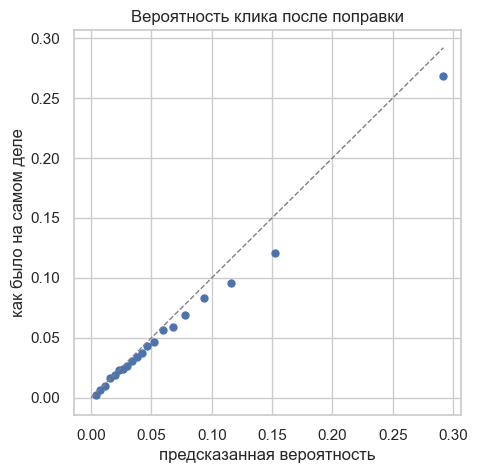

средняя предсказанная вероятность: 0.0604
фактическая доля кликов:           0.0536


In [17]:
edge = train["impression_at"].max().normalize() - pd.Timedelta(days=6)
fit_part, calib_part = train[train["impression_at"] < edge], train[train["impression_at"] >= edge]

helper = CatBoostClassifier(depth=6, learning_rate=0.1, iterations=318,
                            random_seed=42, allow_writing_files=False, thread_count=4, verbose=False)
helper.fit(Pool(fit_part[FEATURES], fit_part["target_click"], cat_features=CAT_COLS))
p_calib = helper.predict_proba(calib_part[FEATURES])[:, 1]


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)


click_calib = LogisticRegression().fit(logit(p_calib), calib_part["target_click"])
p_click = click_calib.predict_proba(logit(p_click))[:, 1]

bins = pd.qcut(p_click, 20, duplicates="drop")
curve = pd.DataFrame({"предсказано": p_click, "факт": test["target_click"].to_numpy()}).groupby(bins).mean()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, curve.max().max()], [0, curve.max().max()], "--", color="grey", linewidth=1)
ax.scatter(curve["предсказано"], curve["факт"], s=25)
ax.set_xlabel("предсказанная вероятность")
ax.set_ylabel("как было на самом деле")
ax.set_title("Вероятность клика после поправки")
plt.show()

print(f"средняя предсказанная вероятность: {p_click.mean():.4f}")
print(f"фактическая доля кликов:           {test['target_click'].mean():.4f}")

## 8. Модель конверсии

Вторая ступень: учится только на кликах. Признаки те же самые, потому что оценка
делается в момент показа, когда клика ещё не было.

In [18]:
train2 = train[train["stage2"]]
test2 = test[test["stage2"]]

conv_model = CatBoostClassifier(depth=8, learning_rate=0.05, iterations=205,
                                random_seed=42, allow_writing_files=False, thread_count=4, verbose=100)
conv_model.fit(Pool(train2[FEATURES], train2["target_conversion"], cat_features=CAT_COLS))

p_conv_test = conv_model.predict_proba(test2[FEATURES])[:, 1]
print(f"\nROC-AUC: {roc_auc_score(test2['target_conversion'], p_conv_test):.4f}")
print(f"для сравнения, простая статистика связки: "
      f"{roc_auc_score(test2['target_conversion'], test2['cr_link']):.4f}")

0:	learn: 0.6635634	total: 403ms	remaining: 1m 22s


100:	learn: 0.3806396	total: 23.5s	remaining: 24.2s


200:	learn: 0.3710512	total: 46s	remaining: 915ms


204:	learn: 0.3706800	total: 47.2s	remaining: 0us



ROC-AUC: 0.8873
для сравнения, простая статистика связки: 0.8533


Общая цифра здесь обманчива, поэтому смотрю отдельно на предложения с историей
и без неё.

In [19]:
with_history = ~test2["offer_id"].isin(new_offers)

def group_auc(y, p):
    return roc_auc_score(y, p) if pd.Series(y).nunique() == 2 else np.nan

rows = []
for name, mask in [("предложения с историей", with_history), ("предложения без истории", ~with_history)]:
    rows.append((name, int(mask.sum()),
                 group_auc(test2.loc[mask, "target_conversion"], p_conv_test[mask.to_numpy()]),
                 group_auc(test2.loc[mask, "target_conversion"], test2.loc[mask, "cr_link"])))
compare = pd.DataFrame(rows, columns=["группа", "кликов", "модель", "статистика связки"]).set_index("группа")
display(compare.round(4))

,кликов,модель,статистика связки
группа,,,
предложения с историей,46540,0.8983,0.8586
предложения без истории,3509,0.6855,0.7218


Сравниваю качество на известных и новых предложениях по таблице выше.
Средний результат может скрывать ошибку на новой связке. Вероятности второй
модели поправляю тем же способом, что и первой.


In [20]:
helper2 = CatBoostClassifier(depth=8, learning_rate=0.05, iterations=205,
                             random_seed=42, allow_writing_files=False, thread_count=4, verbose=False)
fit_part2 = train2[train2["impression_at"] < edge]
calib_part2 = train2[train2["impression_at"] >= edge]
helper2.fit(Pool(fit_part2[FEATURES], fit_part2["target_conversion"], cat_features=CAT_COLS))
conv_calib = LogisticRegression().fit(
    logit(helper2.predict_proba(calib_part2[FEATURES])[:, 1]),
    calib_part2["target_conversion"])

p_conv_raw = conv_model.predict_proba(test[FEATURES])[:, 1]
p_conv = conv_calib.predict_proba(logit(p_conv_raw))[:, 1]
print(f"средняя вероятность конверсии при клике: {p_conv.mean():.3f}")

средняя вероятность конверсии при клике: 0.372


## 9. Ожидаемый доход и сравнение всех решений

Для выбора карточки использую прогноз:

$$\widehat{R}_i = \widehat{P}(\text{клик}_i)\,
\widehat{P}(\text{конверсия}_i\mid\text{клик}_i)\,C_i,$$

где $C_i$ это последняя известная до показа выплата по связке. Карточку
с наибольшим прогнозом ставлю первой. В итоговой метрике беру её фактический
доход из данных, включая ноль при отсутствии конверсии:

$$M = \frac{1}{B}\sum_{b=1}^{B} r_{i_b},\qquad
i_b = \arg\max_{i\in b}\widehat{R}_i.$$

Здесь $B$ это число витрин, $r_i$ равен сумме conversion_payout и conversion_bonus
при целевой конверсии и нулю в остальных случаях. Единица метрики: рубли
на выбранную первую карточку. Предсказанный доход не подставляю вместо фактического.

Все правила сравниваю на одних витринах с минимум двумя карточками и известной
ставкой каждой карточки. NDCG дополнительно оценивает весь порядок по наблюдённому
доходу. Сравнение произведения двух вероятностей с той же формулой, умноженной
на выплату, показывает влияние стоимости конверсии при одинаковых прогнозах.

Это сравнение на исторических откликах прежнего порядка карточек. Оно не измеряет
прирост дохода после изменения порядка в сервисе.


In [21]:
test = test.copy()
test["expected_revenue"] = p_click * p_conv * test["payout_link"]

# Полные исторические витрины до исключения отдельных показов без ставки.
show = df[(df["impression_at"] >= border) & df["advertising_type"].eq("showcase")].copy()
show = show[show.groupby("advertising_impression_id")["target_click"].transform("size") >= 2]
all_showcases = show["advertising_impression_id"].nunique()
# Не удаляю отдельные карточки: у всех сравниваемых правил одинаковый полный пул.
complete_payout = show["payout_link"].notna().groupby(show["advertising_impression_id"]).transform("all")
show = show[complete_payout].copy()
show["expected_revenue"] = test.loc[show.index, "expected_revenue"]
print(f"Витрин с известной ставкой всех карточек: "
      f"{show['advertising_impression_id'].nunique():,} из {all_showcases:,}")
tie = np.random.rand(len(show))


def rank_metrics(order):
    """Сортирует карточки внутри витрины и считает две метрики."""
    ranked = pd.DataFrame({
        "block": show["advertising_impression_id"].to_numpy(),
        "order": np.asarray(order, dtype=float),
        "tie": tie,
        "revenue": show["revenue"].to_numpy(),
    }).sort_values(["block", "order", "tie"], ascending=[True, False, True])
    ranked["place"] = ranked.groupby("block", sort=False).cumcount() + 1

    ideal = ranked.sort_values(["block", "revenue"], ascending=[True, False])
    ideal["place"] = ideal.groupby("block", sort=False).cumcount() + 1

    dcg = (ranked["revenue"] / np.log2(ranked["place"] + 1)).groupby(ranked["block"]).sum()
    ideal_dcg = (ideal["revenue"] / np.log2(ideal["place"] + 1)).groupby(ideal["block"]).sum()
    ndcg = (dcg / ideal_dcg.replace(0, np.nan)).dropna().mean()
    top_revenue = ranked[ranked["place"] == 1]["revenue"].mean()
    return ndcg, top_revenue


solutions = {
    "случайный порядок": np.random.rand(len(show)),
    "популярность (CTR оффера)": show["ctr_offer"],
    "цена из справочника": show["payout_nominal"],
    "доход по статистике": show["ctr_link"] * show["cr_link"] * show["payout_link"],
    "модель клика": p_click[test.index.isin(show.index)],
    "клик × конверсия (без выплаты)": (p_click * p_conv)[test.index.isin(show.index)],
    "ожидаемый доход (модель)": show["expected_revenue"],
}

summary = pd.DataFrame([(name, *rank_metrics(order)) for name, order in solutions.items()],
                       columns=["решение", "NDCG по доходу", "доход первой карточки"]).set_index("решение")
summary["доля от идеала"] = summary["доход первой карточки"] / rank_metrics(show["revenue"])[1]
display(summary.round(4))
print(f"витрин в сравнении: {show['advertising_impression_id'].nunique():,}".replace(",", " "))

# Прогнозы нужны для проверки вероятностей в дополнительном исследовании.
recheck = Path.cwd().parent / "cache" / "recheck"
recheck.mkdir(exist_ok=True)
predictions = test[["impression_at", "partner_offer_id", "offer_id", "visitor_id",
                    "target_click", "target_conversion", "payout_link", "revenue"]].copy()
for name, values in [("p_click_raw", p_click_raw), ("p_click", p_click),
                     ("p_conv_raw", p_conv_raw), ("p_conv", p_conv)]:
    predictions[name] = values
predictions.to_parquet(recheck / "step1-predictions.parquet", index=False)
summary.to_csv(recheck / "step1-ranking.csv")


Витрин с известной ставкой всех карточек: 86,347 из 86,969


,NDCG по доходу,доход первой карточки,доля от идеала
решение,,,
случайный порядок,0.5210,4.0139,0.1314
популярность (CTR оффера),0.7165,20.7292,0.6787
цена из справочника,0.6312,20.2106,0.6617
доход по статистике,0.6270,19.8663,0.6504
модель клика,0.7278,20.7785,0.6803
клик × конверсия (без выплаты),0.7633,20.1665,0.6603
ожидаемый доход (модель),0.7093,21.1168,0.6914


витрин в сравнении: 86 347


Отдельно рассматриваю витрины, где выбор полной модели отличается от популярности.
Этот срез помогает понять различия решений, но не заменяет результат на всех
витринах. В таблице выше равные оценки разрешаются случайным ключом, а в срезе
ниже берётся первый максимум; это различие нужно учитывать при сопоставлении.

In [22]:
def top_choice(order):
    """Какую карточку решение поставило на первое место в каждой витрине."""
    idx = pd.Series(np.asarray(order, dtype=float), index=show.index).groupby(
        show["advertising_impression_id"]).idxmax()
    return show.loc[idx, ["advertising_impression_id", "offer_id", "revenue"]].set_index("advertising_impression_id")


by_model = top_choice(show["expected_revenue"])
by_popularity = top_choice(show["ctr_offer"])
differs = by_model["offer_id"] != by_popularity["offer_id"]

print(f"выбор разошёлся в {differs.sum():,} витринах из {len(by_model):,} ({differs.mean():.1%})".replace(",", " "))
display(pd.DataFrame({
    "доход первой карточки": [by_model.loc[differs, "revenue"].mean(),
                              by_popularity.loc[differs, "revenue"].mean()],
}, index=["ожидаемый доход (модель)", "популярность"]).round(2))

выбор разошёлся в 17 407 витринах из 86 347 (20.2%)


,доход первой карточки
ожидаемый доход (модель),2.32
популярность,0.40


## 10. Выводы

Стоимость конверсии восстанавливаю по последней известной выплате по связке
оффера и партнёрской сети. На 20 120 сентябрьских конверсиях с историей ставка
совпала с фактической выплатой в 99,98% случаев, MAE составила 0,0027 рубля.
Это подтверждает точность восстановления стоимости на проверенном периоде.

Ожидаемый доход учитывает и вероятность отклика, и стоимость конверсии.
На 86 347 одинаковых витринах формула с выплатой дала 21,1168 рубля исторического
дохода выбранной карточки, без выплаты 20,1665 рубля. Популярность дала
20,7292 рубля. При этом NDCG полной модели ниже популярности.

Денежная метрика отвечает цели увеличения дохода. Метрики вероятностей и NDCG
дополняют её и помогают понять ошибки модели.

## 11. Ограничения работы

До первой конверсии ставка неизвестна, а смена тарифа обнаруживается после
поступления новой суммы. Точность восстановления ставки не гарантирует
точности вероятностей, особенно для новых предложений.

Сохраняю прежний расчёт признаков: общие доли CTR/CR используют всю выборку,
а накопленные отклики не везде учитывают задержку поступления событий.
Ставка из справочника также является снимком на дату выгрузки. Поэтому
сравнение моделей здесь носит исследовательский характер и не доказывает
качество прогноза при использовании только доступной на момент показа информации.
Проверка последней известной выплаты отдельно соблюдает эту границу времени.

Исторический порядок карточек влияет на отклики. Реальный прирост дохода нужно
проверять экспериментом в сервисе. Связки с оплатой за клик в работу не входят.
